## Assignment: Object detection
- Alumno 1:
- Alumno 2:
- Alumno 3:

The goals of the assignment are:
* Put into practice acquired knowledge to detect and recognize objects of interest within a satellite image.

To address this problem, you must choose one of the following options:
*	Implement a sliding window strategy to process the whole image, and then train a classifier that determines whether each window includes or not an object of interest. In this way, you can use previous image classification model to infer the object category.
*	Build a single-stage object detection model (e.g., YOLO, SSD, RetinaNet, etc.).
*	Build a two-stage object detection model (e.g., Faster R-CNN, R-FCN, etc.).

Follow the link below to download the detection data set “xview_detection”: [https://drive.upm.es/s/P7nEf3Bygns7tbM](https://drive.upm.es/s/P7nEf3Bygns7tbM)

In [1]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

2026-03-19 14:24:36.197124: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773930276.376779      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773930276.428275      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773930276.851039      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773930276.851086      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773930276.851088      24 computation_placer.cc:177] computation placer alr

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import requests
import zipfile
import json

url = 'https://drive.upm.es/s/P7nEf3Bygns7tbM/download'
zip_name = 'dataset.zip'
target_file = 'xview_det_train.json'
found_path = None

for root, dirs, files in os.walk("."):
    if target_file in files:
        found_path = os.path.join(root, target_file)
        break

if not found_path:
    if not os.path.exists(zip_name):
        r = requests.get(url, stream=True)
        with open(zip_name, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024):
                f.write(chunk)

    if os.path.getsize(zip_name) < 10000:
        print(f"ERREUR : Le fichier {zip_name} est trop petit. Le lien est invalide ou nécessite une connexion.")
    else:
        # Extraction uniquement si le fichier json n'avait pas été trouvé
        with zipfile.ZipFile(zip_name, 'r') as z:
            z.extractall(".")

        for root, dirs, files in os.walk("."):
            if target_file in files:
                found_path = os.path.join(root, target_file)
                break

if found_path:
    print(f"SUCCÈS : Fichier trouvé à : {found_path}")
    
    with open(found_path) as ifs:
        json_data = json.load(ifs)
    print("Base de données chargée avec succès !")
else:
    print(f"ERREUR : {target_file} reste introuvable après extraction.")

SUCCÈS : Fichier trouvé à : ./xview_det_train.json
Base de données chargée avec succès !


In [3]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [4]:
categories = {0: 'Small car', 1: 'Bus', 2: 'Truck', 3: 'Building'}

In [5]:
import warnings
import rasterio
import numpy as np
import os

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    full_path = os.path.join(BASE_DIR, filename) if ('BASE_DIR' in globals() and BASE_DIR is not None) else filename
    with rasterio.open(full_path, 'r') as src:   # ← context manager
        img = np.zeros((src.height, src.width, src.count), dtype=np.float32)
        for b in range(src.count):
            band = src.read(b + 1).astype(np.float32)
            bmin, bmax = band.min(), band.max()
            img[:, :, b] = (band - bmin) / (bmax - bmin + 1e-6) * 255.0
    return img.astype(np.uint8)

#### Training
Design and train a detector to deal with the “xview_detection” perception task.

In [6]:
import json
import os

json_file = found_path if ('found_path' in globals() and found_path is not None) else '../PROJECT/xview_detection/xview_det_train.json'
if not os.path.exists(json_file):
    raise FileNotFoundError(f"Le fichier json de dataset est introuvable: {json_file}")

with open(json_file) as ifs:
    json_data = json.load(ifs)

BASE_DIR = os.path.dirname(json_file)
print("BASE_DIR:", BASE_DIR)

BASE_DIR: .


In [7]:
import numpy as np
from collections import defaultdict

# Pre-index O(N) au lieu de O(N×M)
ann_index = defaultdict(list)
for ann_elem in json_data['annotations'].values():
    ann_index[ann_elem['image_id']].append(ann_elem)

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img in json_data['images'].values():
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    for json_ann in ann_index[json_img['image_id']]:
        obj = GenericObject()
        obj.id = json_ann['image_id']
        obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]),
                  int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
        obj.category = json_ann['category_id']
        counts[obj.category] += 1
        image.add_object(obj)
    anns.append(image)
print(counts)

{'Small car': 188300, 'Bus': 6269, 'Truck': 10600, 'Building': 275943}


In [8]:
from sklearn.model_selection import train_test_split

anns_train, anns_valid = train_test_split(anns, test_size=0.1, random_state=1, shuffle=True)

# Sur-échantillonnage des images contenant Bus ou Truck (×5)
bus_truck_anns = [a for a in anns_train if any(
    o.category in ['Bus', 'Truck'] for o in a.objects
)]
anns_train = anns_train + bus_truck_anns * 4

print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))
print(f'Bus/Truck images dupliquées : {len(bus_truck_anns)} × 5 = {len(bus_truck_anns)*5}')

Number of training images: 19933
Number of validation images: 761
Bus/Truck images dupliquées : 3272 × 5 = 16360


In [9]:
import keras_cv

print('Load model')
prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format='xyxy',
    from_logits=False,
    confidence_threshold=0.05,
    iou_threshold=0.5
)
model = keras_cv.models.YOLOV8Detector.from_preset(
    preset='yolo_v8_s_backbone_coco',
    num_classes=len(categories),
    load_weights=True,
    bounding_box_format='xyxy',
    prediction_decoder=prediction_decoder
)
model.summary()

Load model


I0000 00:00:1773930983.166659      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "yolov8_detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, None,     │  5,089,760 │ input_layer_1[0]… │
│ (Functional)        │ None, 128),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 256),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 512)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat (Repeat)     │ (None, None,      │          0 │ functional[0][2]  │
│                     │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_1 (Repeat)   │ (None, None,      │          0 │ repeat[0][0]      │
│                     │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, None,      │          0 │ repeat_1[0][0],   │
│ (Concatenate)       │ None, 768)        │            │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_co… │ (None, None,      │    196,608 │ concatenate_5[0]… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_bn  │ (None, None,      │      1,024 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre     │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_4 (Split)     │ [(None, None,     │          0 │ pa_fpn_p4p5_pre[… │
│                     │ None, 128),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 128)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ split_4[0][1]     │
│ (ZeroPadding2D)     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │    147,456 │ pa_fpn_p4p5_pre_… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │        512 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_1 │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (ZeroPadding2D)     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │    147,456 │ pa_fpn_p4p5_pre_

 Total params: 13,209,772 (50.39 MB)

 Trainable params: 13,187,436 (50.31 MB)

 Non-trainable params: 22,336 (87.25 KB)

In [10]:
from tensorflow.keras.losses import BinaryCrossentropy

batch_size = 4
total_steps = (len(anns_train) // batch_size) * 25
warmup_steps = int(0.05 * total_steps)

# Gel partiel : 60% premières couches du backbone
layers = model.backbone.layers
freeze_until = int(len(layers) * 0.6)
for layer in layers[:freeze_until]:
    layer.trainable = False
for layer in layers[freeze_until:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=2e-3),
    classification_loss=BinaryCrossentropy(from_logits=False),
    box_loss='ciou',
    jit_compile=False
)

In [11]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ModelCheckpoint
from tensorflow.keras.losses import BinaryCrossentropy

class UnfreezeBackbone(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        if epoch == 5:
            for layer in self.model.backbone.layers:
                layer.trainable = True
            self.model.optimizer.learning_rate = 2e-5
            self.model.optimizer.weight_decay = 2e-3
            print("\nBackbone dégelé intégralement, LR → 2e-5")

model_checkpoint = ModelCheckpoint(
    'model.keras', monitor='val_loss', verbose=1, save_best_only=True
)
early_stop = EarlyStopping(
    'val_loss', patience=8, verbose=1, restore_best_weights=True
)
terminate = TerminateOnNaN()
callbacks = [model_checkpoint, early_stop, terminate, UnfreezeBackbone()]

In [12]:
def image_generator(filename, tile, bboxes, categories):
    def load_tiff(filepath):
        img = load_geoimage(filepath.numpy().decode('utf-8'))
        h, w = img.shape[:2]
        if h < 640 or w < 640:
            pad = np.zeros((640, 640, 3), dtype=np.uint8)
            pad[:h, :w] = img
            img = pad
        return img.astype(np.float32)

    img = tf.py_function(load_tiff, [filename], tf.float32)
    img.set_shape([640, 640, 3])
    return {
        'images': img,
        'bounding_boxes': {
            'boxes': bboxes,
            'classes': categories
        }
    }

def ragged_to_dense(inputs):
    from keras_cv import bounding_box
    images = inputs['images']
    if isinstance(images, tf.RaggedTensor):
        images = images.to_tensor()
    return {
        'images': images,
        'bounding_boxes': bounding_box.to_dense(inputs['bounding_boxes'], max_boxes=100)
    }

def dict_to_tuple(inputs):
    return inputs['images'], inputs['bounding_boxes']

def to_images_only(inputs):
    return inputs['images']

_aug_flip = keras_cv.layers.RandomFlip(
    mode='horizontal_and_vertical',
    bounding_box_format='xyxy'
)
_aug_jitter = keras_cv.layers.JitteredResize(
    target_size=(640, 640),
    scale_factor=(0.7, 1.3),
    bounding_box_format='xyxy'
)
_aug_cutout = keras_cv.layers.RandomCutout(
    height_factor=(0.05, 0.15),
    width_factor=(0.05, 0.15),
)
_aug_color_deg = keras_cv.layers.RandomColorDegeneration(factor=0.3)

def _add_noise(inputs):
    images = inputs['images']
    noise = tf.random.normal(shape=tf.shape(images), mean=0.0, stddev=8.0)
    images = tf.clip_by_value(images + noise, 0.0, 255.0)
    return {**inputs, 'images': images}

def _augment_hsv(inputs):
    image = inputs['images'] / 255.0
    image = tf.image.random_hue(image, max_delta=0.015)
    image = tf.image.random_saturation(image, lower=0.5, upper=1.5)
    image = tf.image.random_brightness(image, max_delta=0.4)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0.0, 1.0) * 255.0
    return {**inputs, 'images': image}

def data_augmentation(inputs):
    inputs = _aug_flip(inputs)
    inputs = _aug_jitter(inputs)
    inputs = _aug_cutout(inputs)
    inputs = _aug_color_deg(inputs)
    inputs = _add_noise(inputs)
    return inputs

In [13]:
batch_size = 4  # défini ici pour éviter les dépendances inter-cellules

def xywh_to_xyxy(bb):
    x, y, w, h = bb
    return [x, y, x + w, y + h]

filenames_train, tiles_train, bboxes_train, categories_train = zip(*list(map(
    lambda img_ann: (
        img_ann.filename,
        list(img_ann.tile),
        list([xywh_to_xyxy(obj_ann.bb) for obj_ann in img_ann.objects]),
        list([list(categories.keys())[list(categories.values()).index(obj_ann.category)]
              for obj_ann in img_ann.objects])
    ), anns_train)))

filenames_valid, tiles_valid, bboxes_valid, categories_valid = zip(*list(map(
    lambda img_ann: (
        img_ann.filename,
        list(img_ann.tile),
        list([xywh_to_xyxy(obj_ann.bb) for obj_ann in img_ann.objects]),
        list([list(categories.keys())[list(categories.values()).index(obj_ann.category)]
              for obj_ann in img_ann.objects])
    ), anns_valid)))

ds_train = tf.data.Dataset.from_tensor_slices((
    tf.cast(filenames_train, tf.string),
    tf.cast(tiles_train, tf.int32),
    tf.cast(tf.ragged.constant(bboxes_train), tf.float32).to_tensor(default_value=-1.0),
    tf.cast(tf.ragged.constant(categories_train), tf.float32).to_tensor(default_value=-1.0)
))
ds_valid = tf.data.Dataset.from_tensor_slices((
    tf.cast(filenames_valid, tf.string),
    tf.cast(tiles_valid, tf.int32),
    tf.cast(tf.ragged.constant(bboxes_valid), tf.float32).to_tensor(default_value=-1.0),
    tf.cast(tf.ragged.constant(categories_valid), tf.float32).to_tensor(default_value=-1.0)
))

# ── Par image (avant batch) ──
ds_train = ds_train.map(image_generator, num_parallel_calls=4)
ds_train = ds_train.map(_augment_hsv, num_parallel_calls=4)
ds_valid = ds_valid.map(image_generator, num_parallel_calls=4)

# ── Batch ──
ds_train = ds_train.shuffle(buffer_size=100, reshuffle_each_iteration=True)
ds_train = ds_train.ragged_batch(batch_size=batch_size, drop_remainder=True)
ds_valid = ds_valid.ragged_batch(batch_size=batch_size, drop_remainder=True)

# ── Augmentations batch-level ──
ds_train = ds_train.map(data_augmentation, num_parallel_calls=4)

# ── Conversion dense ──
ds_train = ds_train.map(ragged_to_dense, num_parallel_calls=4)
ds_valid = ds_valid.map(ragged_to_dense, num_parallel_calls=4)

ds_train = ds_train.map(dict_to_tuple, num_parallel_calls=4).prefetch(2)
ds_valid = ds_valid.map(dict_to_tuple, num_parallel_calls=4).prefetch(2)

In [14]:
import numpy as np

print('Training model')
epochs = 25
train_steps, valid_steps = len(ds_train), len(ds_valid)
h = model.fit(ds_train, steps_per_epoch=train_steps, validation_data=ds_valid,
              validation_steps=valid_steps, epochs=epochs, callbacks=callbacks, verbose=1)

best_idx = int(np.argmin(h.history['val_loss']))
best_value = np.min(h.history['val_loss'])
print('Best validation model: epoch ' + str(best_idx+1), ' - val_loss ' + str(best_value))

Training model
Epoch 1/25


I0000 00:00:1773931038.540162      64 cuda_dnn.cc:529] Loaded cuDNN version 91002


4983/4983 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - box_loss: 2.1370 - class_loss: 5.8260e-05 - loss: 2.1370
Epoch 1: val_loss improved from inf to 2.74077, saving model to model.keras
4983/4983 ━━━━━━━━━━━━━━━━━━━━ 1026s 198ms/step - box_loss: 2.1369 - class_loss: 5.8254e-05 - loss: 2.1370 - val_box_loss: 2.7407 - val_class_loss: 2.6969e-05 - val_loss: 2.7408
Epoch 2/25
4983/4983 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - box_loss: 1.8147 - class_loss: 2.0191e-05 - loss: 1.8147
Epoch 2: val_loss did not improve from 2.74077
4983/4983 ━━━━━━━━━━━━━━━━━━━━ 985s 197ms/step - box_loss: 1.8147 - class_loss: 2.0191e-05 - loss: 1.8147 - val_box_loss: 2.8166 - val_class_loss: 2.5461e-05 - val_loss: 2.8166
Epoch 3/25
4983/4983 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - box_loss: 1.7723 - class_loss: 1.9807e-05 - loss: 1.7723
Epoch 3: val_loss did not improve from 2.74077
4983/4983 ━━━━━━━━━━━━━━━━━━━━ 982s 197ms/step - box_loss: 1.7723 - class_loss: 1.9807e-05 - loss: 1.7723 - val_box_loss: 2.8231 - val_class_

#### Validation
Compute validation metrics.

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as col
import numpy as np
%matplotlib inline

def area_intersection(boxes, box):
    xmin = np.maximum(np.min(boxes[:, 0::2], axis=1), np.min(box[0::2]))
    ymin = np.maximum(np.min(boxes[:, 1::2], axis=1), np.min(box[1::2]))
    xmax = np.minimum(np.max(boxes[:, 0::2], axis=1), np.max(box[0::2]))
    ymax = np.minimum(np.max(boxes[:, 1::2], axis=1), np.max(box[1::2]))
    w = np.maximum(xmax - xmin + 1.0, 0.0)
    h = np.maximum(ymax - ymin + 1.0, 0.0)
    return w * h

def area_union(boxes, box):
    area_anns = (np.max(box[0::2])-np.min(box[0::2])+1.0) * (np.max(box[1::2])-np.min(box[1::2])+1.0)
    area_pred = (np.max(boxes[:, 0::2], axis=1)-np.min(boxes[:, 0::2], axis=1)+1.0) * (np.max(boxes[:, 1::2], axis=1)-np.min(boxes[:, 1::2], axis=1)+1.0)
    return area_anns + area_pred - area_intersection(boxes, box)

def calc_iou(boxes, box):
    iou = area_intersection(boxes, box) / area_union(boxes, box)
    max_value = np.max(iou)
    max_index = np.argmax(iou)
    return max_value, max_index

def calc_ap(rec, prec):
    # First append sentinel values at the end
    mrec = np.concatenate(([0.0], rec, [1.0]))
    mpre = np.concatenate(([0.0], prec, [0.0]))
    # Compute the precision envelope
    for i in range(mpre.size-1, 0, -1):
        mpre[i-1] = np.maximum(mpre[i-1], mpre[i])
    # To calculate area under PR curve, look for points where X axis (recall) changes value
    i = np.where(mrec[1:] != mrec[:-1])[0]
    # and sum (\Delta recall) * prec
    ap = np.sum((mrec[i+1] - mrec[i]) * mpre[i+1])
    return ap

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=categories, yticklabels=categories, ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

def draw_precision_recall(precisions, recalls, categories):
    # Draw precision-recall curves for each category
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    plt.axis([0, 1, 0, 1])
    c_dark = list(filter(lambda x: x.startswith('dark'), col.cnames.keys()))
    aps = []
    # Compare categories for a specific algorithm
    for idx in range(len(categories)):
        plt.plot(recalls[idx], precisions[idx], color=c_dark[idx], label=categories[idx], linewidth=4.0)
        aps.append(calc_ap(recalls[idx], precisions[idx]))
    handles, labels = ax.get_legend_handles_labels()
    labels = [str(val + ' [' + "{:.3f}".format(aps[idx]) + ']') for idx, val in enumerate(labels)]
    handles = [h for (ap, h) in sorted(zip(aps, handles), key=lambda x: x[0], reverse=True)]
    labels = [l for (ap, l) in sorted(zip(aps, labels), key=lambda x: x[0], reverse=True)]
    leg = plt.legend(handles, labels, loc='upper right')
    leg.set_zorder(100)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid("on", linestyle="--", linewidth=2.0)
    fig.tight_layout()
    plt.show()

In [16]:
import numpy as np
from tqdm import tqdm

model = tf.keras.models.load_model('model.keras')
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=2e-5, weight_decay=2e-3),
    classification_loss=BinaryCrossentropy(from_logits=False),
    box_loss='ciou',
    jit_compile=False
)

INFER_BATCH = 4

ds_valid_infer = tf.data.Dataset.from_tensor_slices((
    tf.cast(filenames_valid, tf.string),
    tf.cast(tiles_valid, tf.int32),
    tf.cast(tf.ragged.constant(bboxes_valid), tf.float32).to_tensor(default_value=-1.0),
    tf.cast(tf.ragged.constant(categories_valid), tf.float32).to_tensor(default_value=-1.0)
))
ds_valid_infer = ds_valid_infer.map(image_generator, num_parallel_calls=4)
ds_valid_infer = ds_valid_infer.batch(batch_size=INFER_BATCH)
ds_valid_infer = ds_valid_infer.map(ragged_to_dense, num_parallel_calls=4)
ds_valid_infer = ds_valid_infer.map(to_images_only, num_parallel_calls=4).prefetch(2)

all_preds = model.predict(ds_valid_infer, verbose=1)

annotations, predictions = {}, {}
for idx, ann in enumerate(tqdm(anns_valid)):
    annotations.setdefault(ann.filename, {})
    predictions.setdefault(ann.filename, {})
    for obj in ann.objects:
        annotations[ann.filename].setdefault(obj.category, {'bbox': []})
        annotations[ann.filename][obj.category]['bbox'].append(xywh_to_xyxy(obj.bb))

    n_det = int(np.squeeze(all_preds['num_detections'])[idx])
    for i in range(n_det):
        obj = GenericObject()
        bbox = all_preds['boxes'][idx][i]
        obj.bb = (bbox[0], bbox[1], bbox[2], bbox[3])
        obj.category = categories[int(all_preds['classes'][idx][i])]
        obj.score = float(all_preds['confidence'][idx][i])
        predictions[ann.filename].setdefault(obj.category, {'bbox': [], 'confidence': []})
        predictions[ann.filename][obj.category]['bbox'].append(obj.bb)
        predictions[ann.filename][obj.category]['confidence'].append(obj.score)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/serialization_lib.py:734: UserWarning: `compile()` was not called as part of model loading because the model's `compile()` method is custom. All subclassed Models that have `compile()` overridden should also override `get_compile_config()` and `compile_from_config(config)`. Alternatively, you can call `compile()` manually after loading.
  instance.compile_from_config(compile_config)


191/191 ━━━━━━━━━━━━━━━━━━━━ 36s 167ms/step


100%|██████████| 761/761 [00:00<00:00, 3135.77it/s]


In [17]:
threshold = 0.5
default_cls = 'BACKGROUND'
y_true, y_pred = [], []  # confusion matrix
tps, confidences = dict(), dict()  # draw precision-recall curves for each category
for cls in categories.values():
    # Compute TP, FP and FN for each image
    tps[cls], confidences[cls] = [], []
    for f in predictions:
        # Sort 'cls' predictions by confidence for each file
        pred_boxes, pred_confidences = [], []
        if cls in predictions[f].keys():
            for idx in range(len(predictions[f][cls]['bbox'])):
                pred_boxes.append(predictions[f][cls]['bbox'][idx])
                pred_confidences.append(predictions[f][cls]['confidence'][idx])
            sorted_ind = np.argsort(-np.array(pred_confidences))
            pred_boxes = np.array(pred_boxes)[sorted_ind, :]
        pred_boxes = np.array(pred_boxes).astype(float)
        # Define 'cls' annotations for each file
        anno_boxes = []
        if cls in annotations[f].keys():
            anno_boxes = annotations[f][cls]['bbox']
        anno_boxes = np.array(anno_boxes).astype(float)
        # Define horizontal or oriented bounding boxes
        anno_indices = list(range(len(anno_boxes)))
        # Compare a single prediction 'pred_box' with all annotations 'anno_boxes'
        for pred_idx, pred_box in enumerate(pred_boxes):
            # A prediction is correct if its IoU with the ground truth is above the threshold
            iou_value, ann_index = calc_iou(anno_boxes, pred_box) if len(anno_boxes) > 0 else (-1, -1)
            if iou_value > threshold and ann_index in anno_indices:
                # TP
                anno_indices.remove(int(ann_index))
                tps[cls] += [1.0]
                y_true += [cls]
            else:
                # FP
                tps[cls] += [0.0]
                y_true += [default_cls]
            y_pred += [cls]
            confidences[cls] += [pred_confidences[pred_idx]]
        # FN
        y_true += [cls] * len(anno_indices)
        y_pred += [default_cls] * len(anno_indices)
y_true, y_pred = np.array(y_true), np.array(y_pred)

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score

# Compute AP metric
precision_list, recall_list, ap_list = [], [], []
for cls in categories.values():
    sorted_ind = np.argsort(-np.array(confidences[cls]))
    tp = np.cumsum(np.array(tps[cls])[sorted_ind], dtype=float)
    recall = np.array([0.0]) if len(tp) == 0 else tp / np.maximum(np.sum(y_true == cls), np.finfo(np.float64).eps)
    precision = np.array([0.0]) if len(tp) == 0 else tp / np.maximum(list(range(1, np.sum(y_pred == cls)+1)), np.finfo(np.float64).eps)
    ap = calc_ap(recall, precision)
    print('> %s: Recall: %.3f%% Precision: %.3f%% AP: %.3f%%' % (cls, recall[-1]*100, precision[-1]*100, ap*100))
    precision_list.append(precision)
    recall_list.append(recall)
    ap_list.append(ap)
mean_ap = np.mean(ap_list)
print('mAccuracy: %.3f%%' % (accuracy_score(y_true, y_pred)*100))
print('mRecall: %.3f%%' % (recall_score(y_true, y_pred, average='macro', zero_division=1)*100))
print('mPrecision: %.3f%%' % (precision_score(y_true, y_pred, average='macro', zero_division=1)*100))
print('mAP: %.3f%%' % (mean_ap*100))

> Small car: Recall: 8.714% Precision: 8.115% AP: 0.928%
> Bus: Recall: 0.000% Precision: 0.000% AP: 0.000%
> Truck: Recall: 0.000% Precision: 0.000% AP: 0.000%
> Building: Recall: 8.674% Precision: 14.604% AP: 2.066%
mAccuracy: 5.037%
mRecall: 3.478%
mPrecision: 44.544%
mAP: 0.749%


Confusion matrix:
[[    0 17268     0     0 14566]
 [15976  1525     0     0     0]
 [  640     0     0     0     0]
 [ 1044     0     0     0     0]
 [26226     0     0     0  2491]]


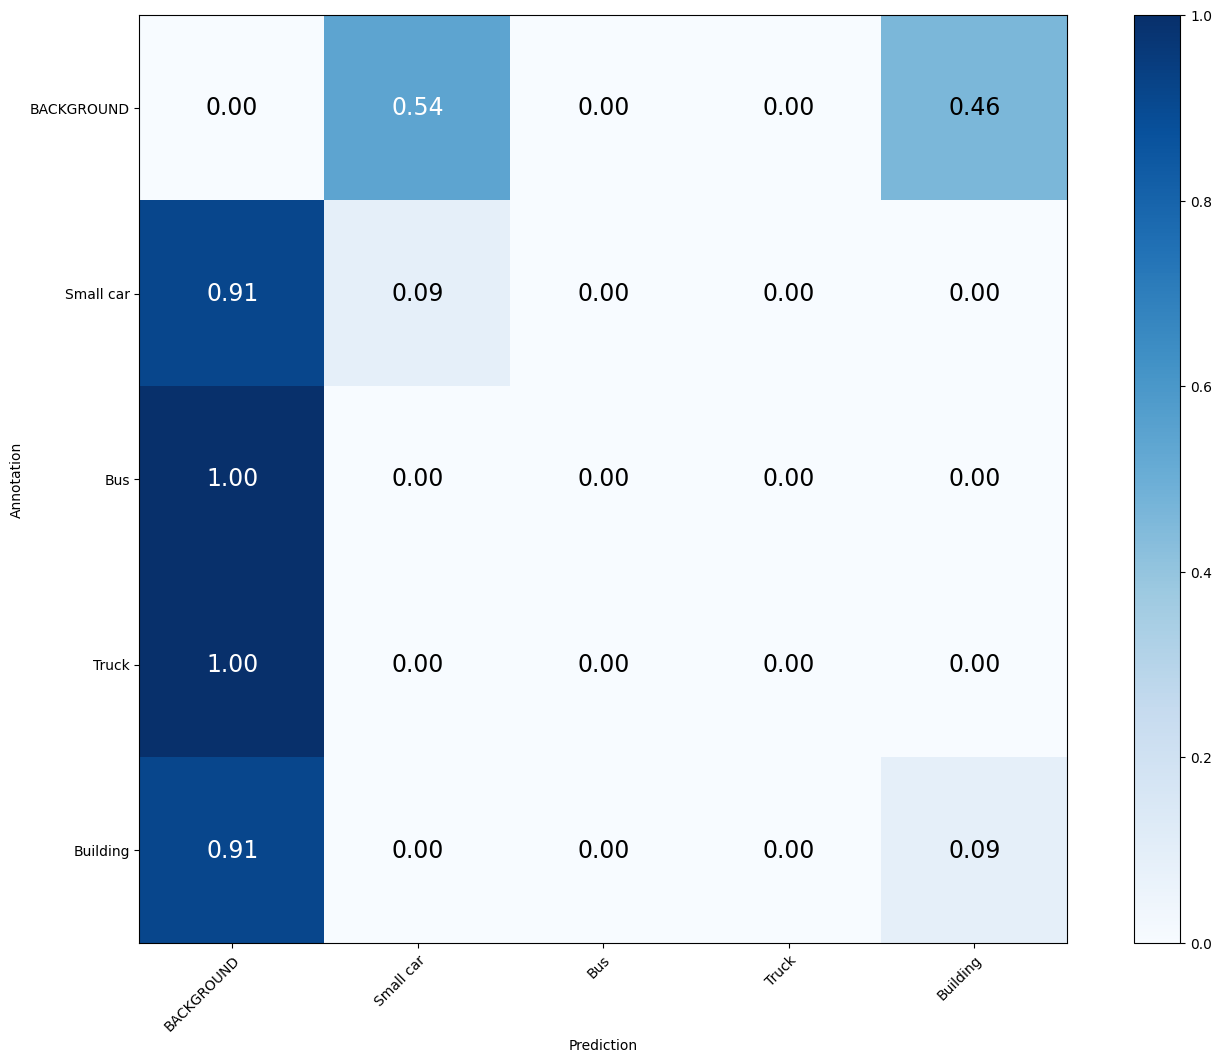

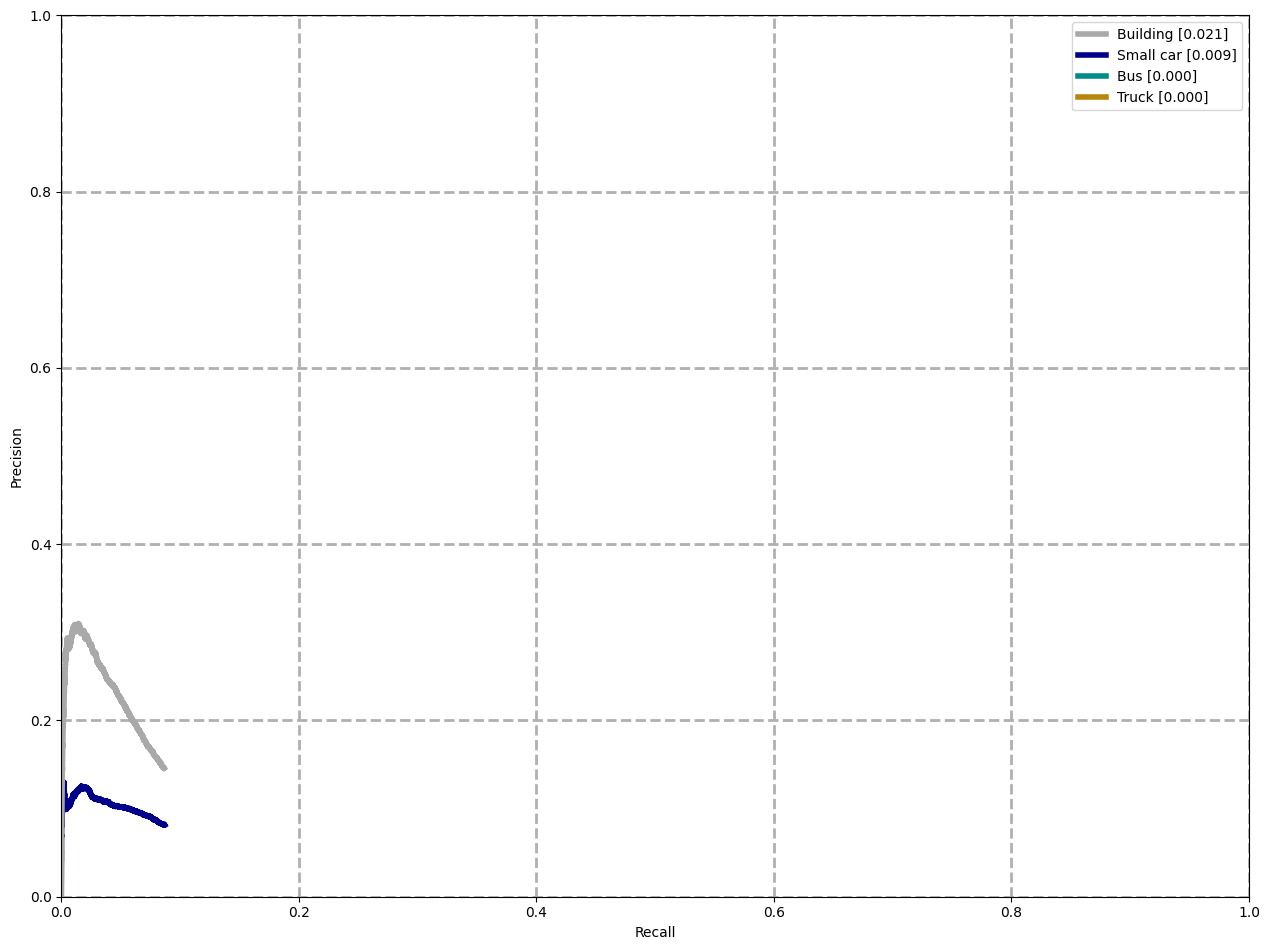

In [19]:
names = list(categories.values()).copy()
names.insert(0, default_cls)
cm = confusion_matrix(y_true, y_pred, labels=names)
print('Confusion matrix:')
print(cm)
draw_confusion_matrix(cm, names)
draw_precision_recall(precision_list, recall_list, categories)

#### Testing
Try to improve the results provided in the competition.

In [20]:
import os
import numpy as np

# Cherche le dossier xview_test dans l'arborescence courante
test_dir = None
for root, dirs, files in os.walk('.'):
    if 'xview_test' in dirs:
        test_dir = os.path.join(root, 'xview_test')
        break

if test_dir is None:
    raise FileNotFoundError("Dossier xview_test introuvable. Vérifie l'extraction du dataset.")

anns = []
for (dirpath, dirnames, filenames) in os.walk(test_dir):
    for filename in filenames:
        # Chemin relatif à partir de la racine du dataset (même convention que le train)
        rel_path = os.path.relpath(os.path.join(dirpath, filename), start='.')
        image = GenericImage(rel_path)
        image.tile = np.array([0, 0, 640, 640])
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 852


In [21]:
import numpy as np
from tqdm import tqdm
import json
from tensorflow.keras.losses import BinaryCrossentropy

model = tf.keras.models.load_model('model.keras')
model._prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format='xyxy',
    from_logits=False,
    confidence_threshold=0.05,
    iou_threshold=0.5
)
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=2e-5, weight_decay=2e-3),
    classification_loss=BinaryCrossentropy(from_logits=False),
    box_loss='ciou',
    jit_compile=False
)

filenames_test = [ann.filename for ann in anns]
tiles_test = [list(ann.tile) for ann in anns]
bboxes_test_empty = [[[0, 0, 0, 0]] for _ in anns]
cats_test_empty   = [[0] for _ in anns]

INFER_BATCH = 4

ds_test = tf.data.Dataset.from_tensor_slices((
    tf.cast(filenames_test, tf.string),
    tf.cast(tiles_test, tf.int32),
    tf.cast(tf.ragged.constant(bboxes_test_empty), tf.float32).to_tensor(default_value=-1.0),
    tf.cast(tf.ragged.constant(cats_test_empty),   tf.float32).to_tensor(default_value=-1.0)
))
ds_test = ds_test.map(image_generator, num_parallel_calls=4)
ds_test = ds_test.batch(batch_size=INFER_BATCH)
ds_test = ds_test.map(ragged_to_dense, num_parallel_calls=4)
ds_test = ds_test.map(to_images_only, num_parallel_calls=4).prefetch(2)

all_preds = model.predict(ds_test, verbose=1)

predictions = {}
predictions_data = {"images": {}, "annotations": {}, "categories": categories}
imgs_idx, annos_idx = 0, 0

for idx, ann in enumerate(tqdm(anns)):
    n_det = int(np.squeeze(all_preds['num_detections'])[idx])
    predictions.setdefault(ann.filename, {})
    num_objects = 0
    for i in range(n_det):
        bbox = all_preds['boxes'][idx][i]
        cat  = categories[int(all_preds['classes'][idx][i])]
        conf = float(all_preds['confidence'][idx][i])
        predictions[ann.filename].setdefault(cat, {'bbox': [], 'confidence': []})
        predictions[ann.filename][cat]['bbox'].append(bbox)
        predictions[ann.filename][cat]['confidence'].append(conf)
        num_objects += 1

    predictions_data["images"][imgs_idx] = {
        "image_id": ann.filename.split('/')[-1],
        "filename": ann.filename,
        "num_objects": num_objects,
        "width": 640, "height": 640
    }
    imgs_idx += 1
    for cat in predictions[ann.filename]:
        for i, (bb, conf) in enumerate(zip(
                predictions[ann.filename][cat]['bbox'],
                predictions[ann.filename][cat]['confidence'])):
            # Conversion xyxy → xywh pour l'évaluateur
            x1, y1, x2, y2 = int(bb[0]), int(bb[1]), int(bb[2]), int(bb[3])
            predictions_data["annotations"][annos_idx] = {
                "image_id": ann.filename.split('/')[-1],
                "category_id": cat,
                "bbox": (x1, y1, x2 - x1, y2 - y1),
                "confidence": str(conf)
            }
            annos_idx += 1

with open("prediction.json", "w") as outfile:
    json.dump(predictions_data, outfile)
print(f"Sauvegardé : {annos_idx} détections sur {imgs_idx} images")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/serialization_lib.py:734: UserWarning: `compile()` was not called as part of model loading because the model's `compile()` method is custom. All subclassed Models that have `compile()` overridden should also override `get_compile_config()` and `compile_from_config(config)`. Alternatively, you can call `compile()` manually after loading.
  instance.compile_from_config(compile_config)


213/213 ━━━━━━━━━━━━━━━━━━━━ 33s 144ms/step


100%|██████████| 852/852 [00:00<00:00, 4344.29it/s]


Sauvegardé : 40614 détections sur 852 images
